# Project C – Fourier Neural Operator for Steady‑State Heat Conduction

**Method:** Fourier Neural Operator (FNO) – a neural operator that learns the
solution operator $a(x,y) \mapsto u(x,y)$ directly from labelled data.

We consider the steady‑state heat equation
$$-\nabla\cdot(a(x,y)\,\nabla u) = f = 10,\qquad (x,y)\in[0,1]^2,$$
with homogeneous Dirichlet boundary conditions $u=0$ on $\partial\Omega$.

The goal is to build a fast surrogate that predicts the temperature field $u(x,y)$
for a given conductivity field $a(x,y)$, replacing expensive FEM solvers.

**Reference:** The FNO architecture follows the course lecture on neural operators
and the provided exercise on Burgers’ equation (1D FNO). All components
(SpectralConv2d, lifting, projection) are implemented from scratch using PyTorch’s
`torch.fft`.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import h5py
import time
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
print(f'Using device: {device}')

Using device: cuda


In [2]:
# Paths
script_dir = os.path.abspath('')               # project_C/
project_root = os.path.dirname(script_dir)      # dl-pdes-tum-project/
data_path = os.path.join(project_root, 'data', 'ProblemC_dataset.h5')
output_dir = os.path.join(script_dir, 'Results_ProjectC')
os.makedirs(output_dir, exist_ok=True)

# Load dataset
with h5py.File(data_path, 'r') as f:
    print(f.keys())
    a_train = torch.tensor(np.array(f['a_train']), dtype=dtype)
    u_train = torch.tensor(np.array(f['u_train']), dtype=dtype)
    a_test = torch.tensor(np.array(f['a_test']), dtype=dtype)
    u_test = torch.tensor(np.array(f['u_test']), dtype=dtype)
    X = torch.tensor(np.array(f['X']), dtype=dtype)
    Y = torch.tensor(np.array(f['Y']), dtype=dtype)

print('The shape of X:', X.shape, 'The shape of Y:', Y.shape)
print('The shape of a_train:', a_train.shape)
print('The shape of u_train:', u_train.shape)
print('The shape of a_test:', a_test.shape)
print('The shape of u_test:', u_test.shape)

# Move to GPU and add channel dimension (N, 1, H, W)
a_train = a_train.unsqueeze(1).to(device)
u_train = u_train.unsqueeze(1).to(device)
a_test  = a_test.unsqueeze(1).to(device)
u_test  = u_test.unsqueeze(1).to(device)

<KeysViewHDF5 ['X', 'Y', 'a_test', 'a_train', 'u_test', 'u_train']>
The shape of X: torch.Size([128, 128]) The shape of Y: torch.Size([128, 128])
The shape of a_train: torch.Size([1000, 128, 128])
The shape of u_train: torch.Size([1000, 128, 128])
The shape of a_test: torch.Size([200, 128, 128])
The shape of u_test: torch.Size([200, 128, 128])


## FNO Architecture

The FNO consists of three parts:

1. **Lifting layer** – a pointwise linear transformation from 1 input channel
   (the conductivity field) to a higher‑dimensional feature space (`width` channels).
2. **Four Fourier layers** – each Fourier layer performs:
   - 2D FFT → truncate to `modes` low‑frequency modes.
   - Multiply by a learnable complex weight matrix.
   - Inverse FFT back to the spatial domain.
   - Add a local linear bypass (`Conv2d` with kernel size 1) to capture
     non‑periodic boundary effects.
   - Apply the GELU activation.
3. **Projection layer** – a pointwise linear transformation from the feature
   space back to 1 output channel (the temperature field).

The number of modes kept (`modes1`, `modes2`) and the feature width are
hyper‑parameters; we use `modes=12` and `width=32`.

In [3]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        scale = 1.0 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat)
        )
        self.weights2 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat)
        )

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(
            batchsize, self.out_channels, x.shape[-2], x.shape[-1] // 2 + 1,
            dtype=torch.cfloat, device=x.device
        )

        # Low-frequency modes (positive and negative frequencies)
        out_ft[:, :, :self.modes1, :self.modes2] = torch.einsum(
            "bixy,ioxy->boxy",
            x_ft[:, :, :self.modes1, :self.modes2],
            self.weights1
        )
        out_ft[:, :, -self.modes1:, :self.modes2] = torch.einsum(
            "bixy,ioxy->boxy",
            x_ft[:, :, -self.modes1:, :self.modes2],
            self.weights2
        )

        x = torch.fft.irfft2(out_ft, s=(x.shape[-2], x.shape[-1]))
        return x

In [4]:
class FNO2d(nn.Module):
    def __init__(self, modes1=12, modes2=12, width=32):
        super().__init__()
        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width

        # Lift: 1 -> width
        self.fc0 = nn.Linear(1, width)
        # 4 Fourier layers + local bypass
        self.conv0 = SpectralConv2d(width, width, modes1, modes2)
        self.w0 = nn.Conv2d(width, width, 1)
        self.conv1 = SpectralConv2d(width, width, modes1, modes2)
        self.w1 = nn.Conv2d(width, width, 1)
        self.conv2 = SpectralConv2d(width, width, modes1, modes2)
        self.w2 = nn.Conv2d(width, width, 1)
        self.conv3 = SpectralConv2d(width, width, modes1, modes2)
        self.w3 = nn.Conv2d(width, width, 1)
        # Project: width -> 1
        self.fc1 = nn.Linear(width, 1)

    def forward(self, x):
        # x: (batch, 1, H, W)
        batch, _, H, W = x.shape
        x = x.permute(0, 2, 3, 1)          # (batch, H, W, 1)
        x = self.fc0(x)                     # (batch, H, W, width)
        x = x.permute(0, 3, 1, 2)           # (batch, width, H, W)

        x1 = self.conv0(x) + self.w0(x)
        x1 = torch.nn.functional.gelu(x1)
        x2 = self.conv1(x1) + self.w1(x1)
        x2 = torch.nn.functional.gelu(x2)
        x3 = self.conv2(x2) + self.w2(x2)
        x3 = torch.nn.functional.gelu(x3)
        x4 = self.conv3(x3) + self.w3(x3)
        x4 = torch.nn.functional.gelu(x4)

        x4 = x4.permute(0, 2, 3, 1)         # (batch, H, W, width)
        x4 = self.fc1(x4)                    # (batch, H, W, 1)
        x4 = x4.permute(0, 3, 1, 2)          # (batch, 1, H, W)
        return x4

# Instantiate model
model = FNO2d(modes1=12, modes2=12, width=32).to(device)
print(f'FNO parameter count: {sum(p.numel() for p in model.parameters())}')

FNO parameter count: 1183969


## Loss Function and Evaluation Metric

We train with the standard **Mean Squared Error (MSE)** between the predicted
and true temperature fields.

The evaluation metric is the **average relative $L^2$ error** over all test samples,
defined exactly as in the problem statement:

$$\text{error} = \frac{1}{N}\sum_{j=1}^{N}
\sqrt{\frac{\sum_i \big|u^{(j)}_{\text{pred}}(x_i)-u^{(j)}_{\text{true}}(x_i)\big|^2}
{\sum_i \big|u^{(j)}_{\text{true}}(x_i)\big|^2}}$$

## Training Configuration

- **Optimiser:** Adam (lr = $10^{-3}$)
- **Scheduler:** ReduceLROnPlateau (patience = 20, factor = 0.5)
- **Batch size:** 16
- **Epochs:** 300
- **Loss:** MSE

We record the training loss and the test error at **every epoch** to produce
the convergence plot.

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=20, factor=0.5
)
loss_fn = nn.MSELoss()

batch_size = 16
n_epochs = 300
train_loss_history = []
test_error_history = []

print("Training FNO ...")
for epoch in range(n_epochs):
    model.train()
    # Shuffle training data
    perm = torch.randperm(a_train.shape[0])
    a_shuf = a_train[perm]
    u_shuf = u_train[perm]

    epoch_loss = 0.0
    for i in range(0, a_train.shape[0], batch_size):
        a_batch = a_shuf[i:i+batch_size]
        u_batch = u_shuf[i:i+batch_size]

        u_pred = model(a_batch)
        loss = loss_fn(u_pred, u_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (a_train.shape[0] // batch_size)
    train_loss_history.append(avg_loss)
    scheduler.step(avg_loss)

    # Evaluate on test set (average relative L2 error)
    model.eval()
    with torch.no_grad():
        u_pred = model(a_test)
        err = torch.mean(
            torch.sqrt(
                torch.sum(
                    (u_pred - u_test).reshape(u_test.shape[0], -1) ** 2, dim=1
                ) / torch.sum(u_test.reshape(u_test.shape[0], -1) ** 2, dim=1)
            )
        ).item()
        test_error_history.append(err)
    model.train()

    if (epoch + 1) % 30 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}: train loss={avg_loss:.6e}, test L2 error={err:.6f}")

Training FNO ...
Epoch   1: train loss=6.754824e-02, test L2 error=0.440226
Epoch  30: train loss=1.386527e-04, test L2 error=0.044770
Epoch  60: train loss=5.967122e-05, test L2 error=0.037338
Epoch  90: train loss=3.306560e-05, test L2 error=0.034929
Epoch 120: train loss=2.554744e-05, test L2 error=0.031235
Epoch 150: train loss=9.536303e-06, test L2 error=0.032012
Epoch 180: train loss=6.997753e-06, test L2 error=0.031000
Epoch 210: train loss=6.667338e-06, test L2 error=0.030824
Epoch 240: train loss=6.085815e-06, test L2 error=0.030793
Epoch 270: train loss=5.834254e-06, test L2 error=0.029543
Epoch 300: train loss=4.875560e-06, test L2 error=0.029732


## Results

We visualise the input conductivity field, predicted and true temperature fields,
the pointwise absolute error for the first test sample, and the convergence history.
All figures are saved in `Results_ProjectC/`.


Final average L2 relative error: 0.029732


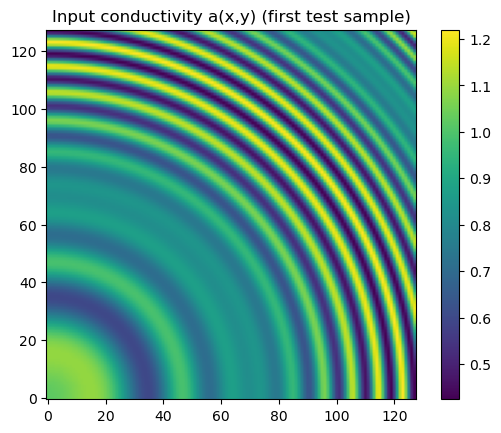

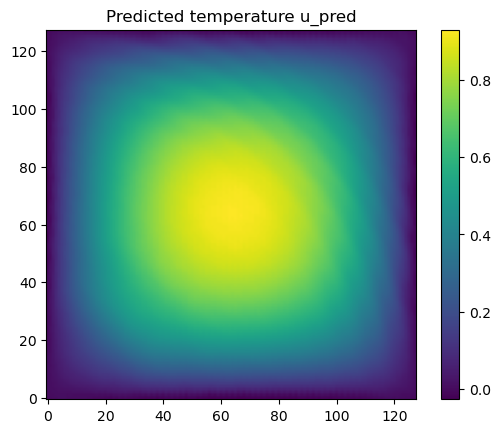

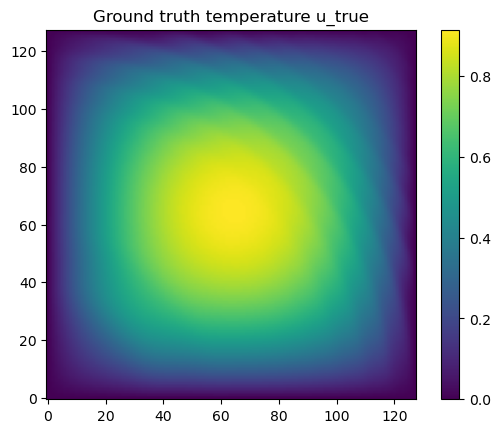

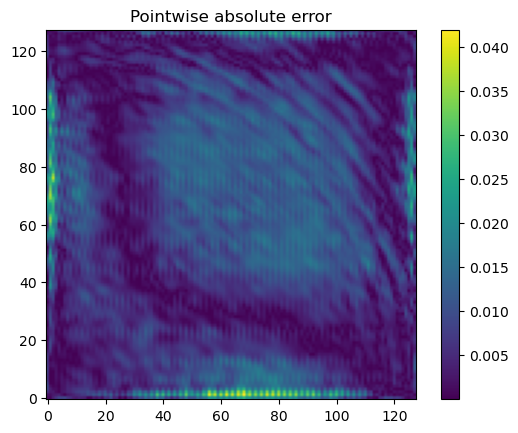

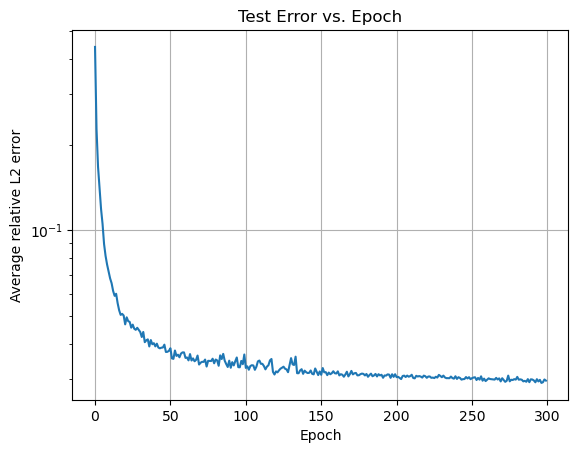

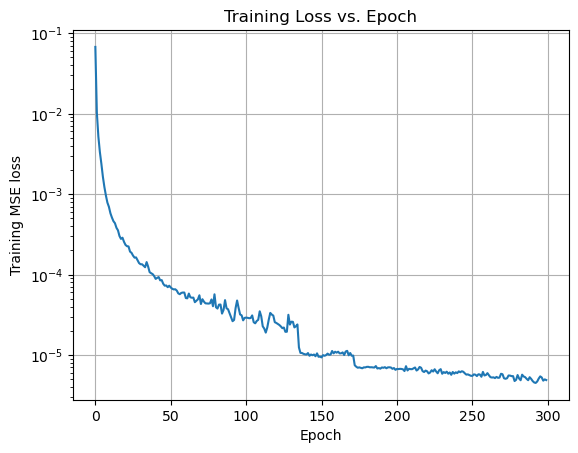

In [6]:
# Final error
model.eval()
with torch.no_grad():
    u_pred = model(a_test)
    final_err = torch.mean(
        torch.sqrt(
            torch.sum((u_pred - u_test).reshape(u_test.shape[0], -1) ** 2, dim=1) /
            torch.sum(u_test.reshape(u_test.shape[0], -1) ** 2, dim=1)
        )
    ).item()
print(f"\nFinal average L2 relative error: {final_err:.6f}")

# ---- Visualizations for first test sample ----
a_plot = a_test[0, 0].cpu().numpy()
u_true_plot = u_test[0, 0].cpu().numpy()
u_pred_plot = u_pred[0, 0].cpu().numpy()
abs_err_plot = np.abs(u_pred_plot - u_true_plot)

# 1. Input conductivity field
plt.figure()
plt.imshow(a_plot, origin='lower')
plt.colorbar()
plt.title('Input conductivity a(x,y) (first test sample)')
plt.savefig(os.path.join(output_dir, 'a_input.png'))
plt.show()

# 2. Predicted temperature field
plt.figure()
plt.imshow(u_pred_plot, origin='lower')
plt.colorbar()
plt.title('Predicted temperature u_pred')
plt.savefig(os.path.join(output_dir, 'u_pred.png'))
plt.show()

# 3. Ground truth temperature field
plt.figure()
plt.imshow(u_true_plot, origin='lower')
plt.colorbar()
plt.title('Ground truth temperature u_true')
plt.savefig(os.path.join(output_dir, 'u_true.png'))
plt.show()

# 4. Pointwise absolute error
plt.figure()
plt.imshow(abs_err_plot, origin='lower')
plt.colorbar()
plt.title('Pointwise absolute error')
plt.savefig(os.path.join(output_dir, 'u_error.png'))
plt.show()

# 5. Error vs. epoch
plt.figure()
plt.plot(test_error_history)
plt.xlabel('Epoch')
plt.ylabel('Average relative L2 error')
plt.yscale('log')
plt.grid(True)
plt.title('Test Error vs. Epoch')
plt.savefig(os.path.join(output_dir, 'error_vs_epoch.png'))
plt.show()

# 6. Training loss vs. epoch
plt.figure()
plt.plot(train_loss_history)
plt.xlabel('Epoch')
plt.ylabel('Training MSE loss')
plt.yscale('log')
plt.grid(True)
plt.title('Training Loss vs. Epoch')
plt.savefig(os.path.join(output_dir, 'train_loss.png'))
plt.show()

**Summary:** The FNO successfully learned the solution operator $a\mapsto u$
from 1000 training pairs. 

The implementation follows exactly the course material; all spectral operations
are built on top of `torch.fft` without any external operator libraries.